## Project Title

Jude-Telecom Churn Dataset

## Problem Statement

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."



## Propose Solution

Here are the proposed solution workflow.

1.Data preprocessing & Cleaning

2.Feature Engineering & Transformation

3.Data Spliting & Handling Class Imbalance

4.Model Selection & Training

5.Model Evaluation & Interpretation





In [1]:
## Dataset Description

The  Telecom's Churn Dataset, which consists of cleaned customer activity data (features), along with a churn label specifying whether a customer canceled the subscription, will be used to develop predictive models. Two datasets are made available here: The churn-80 and churn-20 datasets can be downloaded.



## import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

## load Dataset

In [3]:
df =pd.read_csv('Telco_Customer_Churn.csv')

## Perform EDA

 Dataset Inspection

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,NaN,0.0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34,Yes,No,DSL,Yes,...,Yes,NaN,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,NaN,No,No,2,Yes,No,NaN,Yes,...,No,NaN,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45,No,No phone service,NaN,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,NaN,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0.0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,NaN,0.0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0.0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1.0,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0.0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3314,2402-TAIRZ,Female,0.0,No,No,37,Yes,No,Fiber optic,No,...,Yes,No,No,No,One year,No,Electronic check,80.05,3019.1,No
740,4381-MHQDC,Female,0.0,No,No,47,Yes,Yes,DSL,Yes,...,Yes,Yes,No,No,Two year,Yes,Mailed check,65.00,2879.9,No
4948,3446-QDSZF,Female,0.0,No,No,4,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,No,Credit card (automatic),55.50,227.35,No
628,2469-DTSGX,Female,1.0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,111.65,7943.45,No
3627,3243-ZHOHY,Female,0.0,No,No,16,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.10,296.15,No
290,7534-BFESC,Male,1.0,No,No,24,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,76.10,1712.7,Yes
6823,7009-LGECI,Female,0.0,No,No,4,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),50.55,235.65,No
1419,3498-LZGQZ,Male,0.0,Yes,Yes,63,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,19.15,1177.05,No
5569,0013-EXCHZ,Female,1.0,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,Yes
2272,8064-RAVOH,Male,0.0,No,Yes,1,Yes,No,DSL,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,49.85,49.85,No


In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7039 non-null   object 
 2   SeniorCitizen     7040 non-null   float64
 3   Partner           7040 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7041 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7041 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7041 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen       float64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
df.isnull().sum()

customerID          0
gender              4
SeniorCitizen       3
Partner             3
Dependents          0
tenure              0
PhoneService        2
MultipleLines       0
InternetService     2
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         2
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
df.select_dtypes(include=['number']).columns.tolist()

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [14]:
df.select_dtypes(include=['object']).columns.tolist()

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [15]:
for col in df.columns:
    print(f"\n{"="*40}")
    print(f"COLUMN: {col}")
    print(f"{"="*40}")   
    print(df[col].value_counts(dropna=False))



COLUMN: customerID
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

COLUMN: gender
gender
Male      3555
Female    3484
NaN          4
Name: count, dtype: int64

COLUMN: SeniorCitizen
SeniorCitizen
0.0    5898
1.0    1142
NaN       3
Name: count, dtype: int64

COLUMN: Partner
Partner
No     3638
Yes    3402
NaN       3
Name: count, dtype: int64

COLUMN: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

COLUMN: tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

COLUMN: PhoneService
PhoneService
Yes    6359
No      682
NaN       2
Name: count, dtype: int64

COLUMN: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count,

OBSERVATIONS.

 This dataset has 7043 rows and 21 columns
- Other columns have the correct data type except the Totalcharges column
- Missing values exist in 6 columns
- There are no duplicate rows in the dataset
- Some columns, such as CustomerID, Gender, & Tenure, did not have the correct naming convention
- There are 11 blank entries in the Total charges column, which made the data type change from float to object
 



Data Cleaning

In [16]:
df['gender'] = df['gender'].fillna("Female")
df['SeniorCitizen'] = df['SeniorCitizen'].fillna(df['SeniorCitizen'].mode()[0])
df['Partner'] = df['Partner'].fillna(df['Partner'].mode()[0])
df['PhoneService'] = df['PhoneService'].fillna("No")
df['InternetService'] = df['InternetService'].fillna("No")
df['TechSupport'] = df['TechSupport'].fillna(df['TechSupport'].mode()[0])
df['TotalCharges'] = df['TotalCharges'].replace({" ": "0.0"}).astype(float)

In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df.dtypes

customerID           object
gender               object
SeniorCitizen       float64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [19]:
df.rename(columns={'customerID': 'CustomerID', 'gender': 'Gender', 'tenure': 'Tenure'}, inplace=True)

In [20]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [21]:
df['TotalCharges'].value_counts(dropna=False)

TotalCharges
0.00       11
20.20      11
19.75       9
20.05       8
19.90       8
           ..
6849.40     1
692.35      1
130.15      1
3211.90     1
6844.50     1
Name: count, Length: 6531, dtype: int64

Data Visualisation

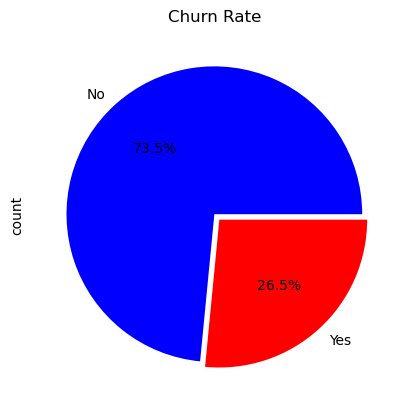

In [22]:
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['blue', 'red'], explode=(0, 0.05))
plt.title('Churn Rate')
plt.show()


OBSERVATION

the chart indicates the total customer No of 73.5% that remain as customers while YES which is 26.5% of already left customers   

1.the diagram show the total number of customers that still with company, NO, which is 2.500 while ,YES, which is are customers left and they are 1.600 in a month

2.the customers that has one year contract are 1.300, while the customer that left(cancelled) the contract in a year are 200.

3.the cuatomers has 2 years contract are 1.600 while the customers that cancelled the contract after 2 years 50. 

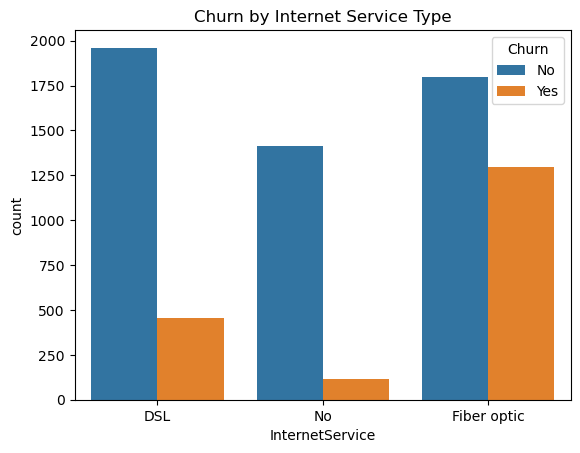

In [23]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service Type')
plt.show()


OBSERVATION

1.customers that cosume more internet on DSL are 1800 still remaining with tbe company while the customers do not use their internet on DSL are 400.
2.No,1350 which is the blue color in the chart stays despite there is no internetService but (Yes),125 orange color left the company due lack of internetService.
3.the fiber optic of the still of the company which are(No) 1850 but fiber optic of those that left the company are (Yes)1250.

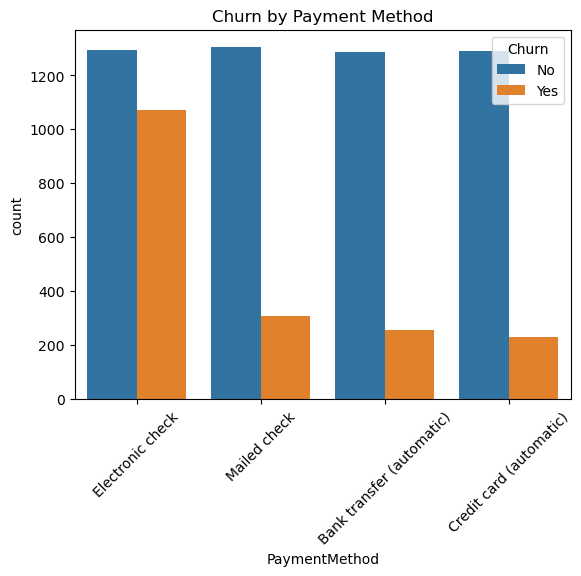

In [24]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()


OBSERVATION,

1.the chart shows that 1300 customer(NO) still with the company paid with Electronic check while customers that left paid 1050 Electronic check.
2.the mail check shows that company sent more mails to the customer with blue color 1300 (No) than that of orange color 300  (Yes).
3.the customers that use Bank transfer are 1300 the (No),while orange color (Yes) are 250
4.the customer that use Credit Card the blue color are 1300 (No) while orange color (Yes) are 200. 

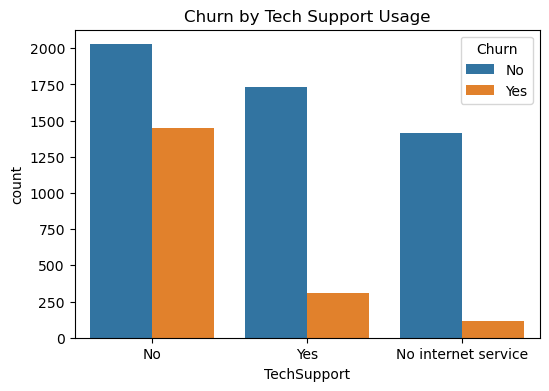

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Churn by Tech Support Usage')
plt.show()


OBSERVATION,

1.the customers that didn't allow Techsupport while still with comany are 2000 while customersd that didn't allow Techsupport that left tghe company are 1400,
2.the customers that agreed for Techsupport while still with the company are 1650, the customers agreed for Techsupport but left the company are 300,
3.the customers that has no internet seervice while still with the company are 1400, the customers that has no internet servuice but left the company are 125.

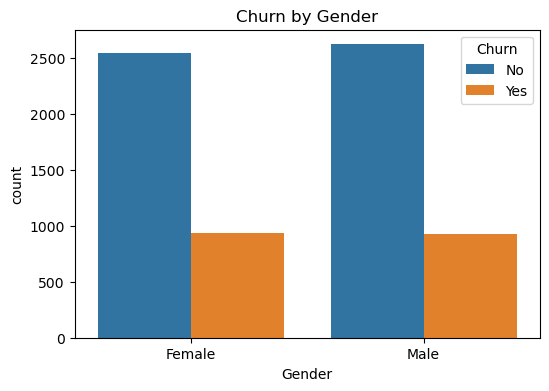

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', hue='Churn')
plt.title('Churn by Gender')
plt.show()

OBSERVATION,

1.the female customers that are still with company are 2500 while female the left the company are 900,

2. the male customers thta are still with company are 2600 while the male customer that left the comany are 900.
   

Feature Engineering

In [27]:
encoders = {}

for column in df:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder


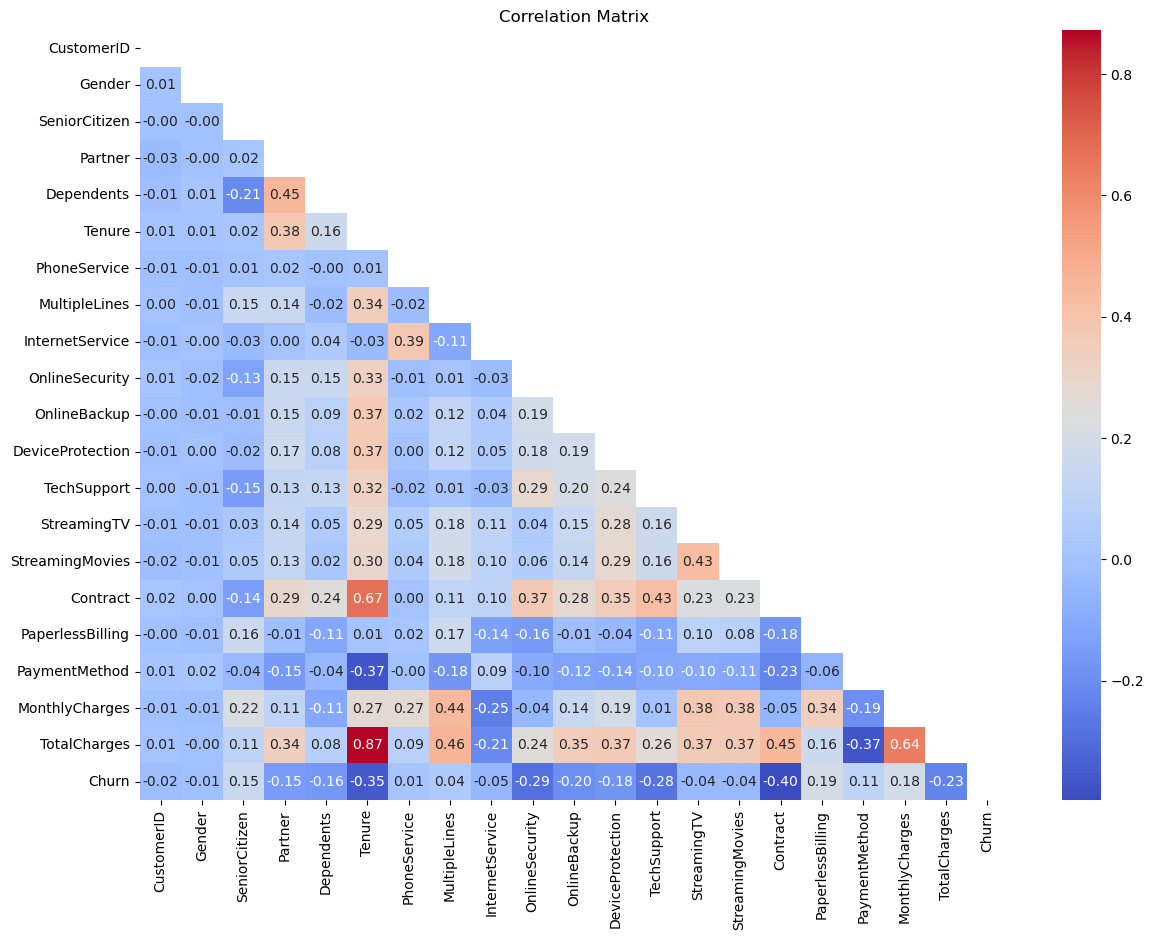

In [28]:
plt.figure(figsize = (14, 10))
cut_upper = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True, cmap = "coolwarm", fmt = ".2f", mask = cut_upper)
plt.title("Correlation Matrix")
plt.show()

In [29]:
for col in df.columns:
    print(f"\n{"="*40}")
    print(f"COLUMN: {col}")
    print(f"{"="*40}")   
    print(df[col].value_counts(dropna=False))



COLUMN: CustomerID
CustomerID
5375    1
2667    1
4267    1
4222    1
3815    1
       ..
6899    1
1807    1
1063    1
3007    1
2226    1
Name: count, Length: 7043, dtype: int64

COLUMN: Gender
Gender
1    3555
0    3488
Name: count, dtype: int64

COLUMN: SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

COLUMN: Partner
Partner
0    3641
1    3402
Name: count, dtype: int64

COLUMN: Dependents
Dependents
0    4933
1    2110
Name: count, dtype: int64

COLUMN: Tenure
Tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

COLUMN: PhoneService
PhoneService
1    6359
0     684
Name: count, dtype: int64

COLUMN: MultipleLines
MultipleLines
0    3390
2    2971
1     682
Name: count, dtype: int64

COLUMN: InternetService
InternetService
1    3096
0    2419
2    1528
Name: count, dtype: int64

COLUMN: OnlineSecurity
OnlineSecurity
0    3498
2    2019
1    1526
Name: co

In [30]:
df_ml = df.drop('CustomerID', axis=1)

In [31]:
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

In [32]:
## to standardize Dataset

In [33]:
scaler = StandardScaler()
df_ml = scaler.fit_transform(df_ml)

Split Dataset

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Train Model

In [35]:
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("========== Random Forest ==========")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall Score:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

========== Random Forest ==========
Accuracy: 0.7970191625266146
Precision: 0.6617100371747212
Recall Score: 0.4772117962466488
F1 Score: 0.5545171339563862

Confusion Matrix
[[945  91]
 [195 178]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



In [36]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
print("========== Logistic Regression ==========")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall Score:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

========== Logistic Regression ==========
Accuracy: 0.8105039034776437
Precision: 0.6743421052631579
Recall Score: 0.5495978552278821
F1 Score: 0.6056129985228951

Confusion Matrix
[[937  99]
 [168 205]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.67      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



C:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluation
print("========== XGBoost ==========")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall Score:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

C:\Users\pc\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:11:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========== XGBoost ==========
Accuracy: 0.801277501774308
Precision: 0.6504854368932039
Recall Score: 0.5388739946380697
F1 Score: 0.5894428152492669

Confusion Matrix
[[928 108]
 [172 201]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.54      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Save Model

In [38]:
# Saving the Random Forest model
joblib.dump(lr_model, 'cusomer_churn_model.pkl')

['cusomer_churn_model.pkl']

conclusion 